In [163]:
#Support Vector Regression (SVR)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [164]:
# Load the dataset
df = pd.read_csv('house.csv')

In [165]:
df.columns

Index(['Rent', 'House size', 'Bedrooms', 'Distance ', 'Age of Property',
       'Bathrooms', 'Security Rating', 'Local Pop. Density',
       'Monthly Income Owner'],
      dtype='str')

In [166]:
df.head()

,Rent,House size,Bedrooms,Distance,Age of Property,Bathrooms,Security Rating,Local Pop. Density,Monthly Income Owner
0,923000,134.7,3,0.50,14.8,3,4.3,4448,370000
1,739000,169.3,4,27.68,5.5,4,4.6,1341,552000
2,701000,81.3,3,3.42,4.9,3,5.7,4157,508000
3,707000,120.1,3,0.50,8.4,3,4.5,7280,461000
4,150000,89.6,2,50.01,3.9,1,8.2,1774,519000


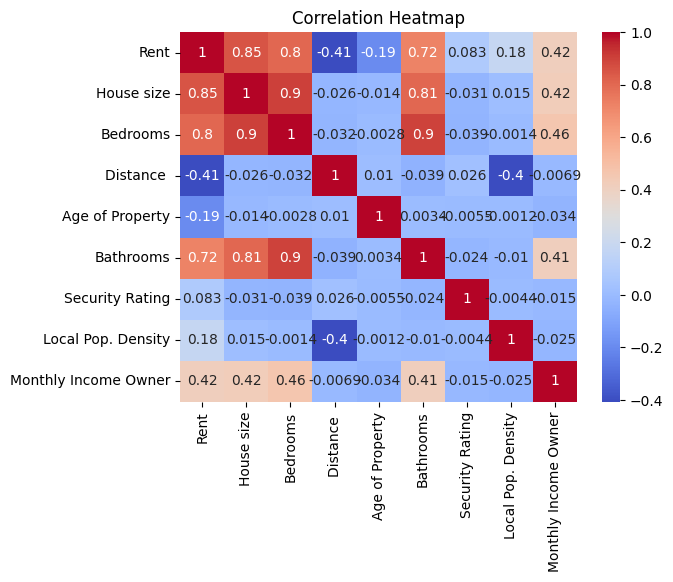

In [167]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

<Axes: xlabel='House size', ylabel='Rent'>

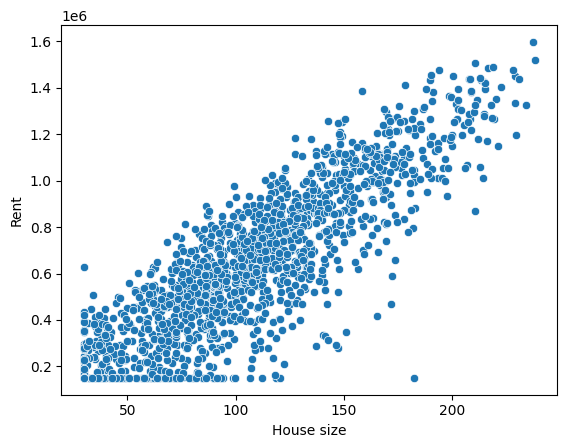

In [168]:
sns.scatterplot(x='House size', y='Rent', data=df)

Text(0.5, 1.0, 'Distribution of Rent')

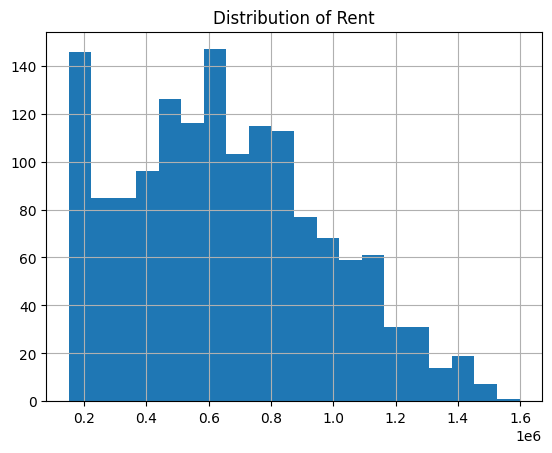

In [169]:
df.hist('Rent', bins=20)
plt.title('Distribution of Rent')

Text(0.5, 1.0, 'Distribution of House Size')

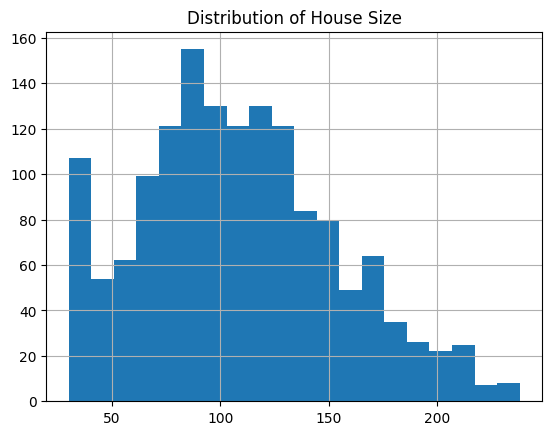

In [170]:
df.hist('House size', bins=20)
plt.title('Distribution of House Size')

In [171]:
x =df.iloc[:, [1, 2, 3, 8]].values
y = df.iloc[:, 0].values.reshape(-1, 1)

In [172]:
print(x)

[[1.347e+02 3.000e+00 5.000e-01 3.700e+05]
 [1.693e+02 4.000e+00 2.768e+01 5.520e+05]
 [8.130e+01 3.000e+00 3.420e+00 5.080e+05]
 ...
 [1.498e+02 4.000e+00 1.620e+00 4.730e+05]
 [1.282e+02 3.000e+00 1.574e+01 5.050e+05]
 [3.000e+01 1.000e+00 1.069e+01 4.330e+05]]


In [173]:
print(y)

[[ 923000]
 [ 739000]
 [ 701000]
 ...
 [1038000]
 [ 841000]
 [ 150000]]


In [174]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [175]:
print(x_train)

[[1.997e+02 5.000e+00 6.790e+00 4.990e+05]
 [7.300e+01 2.000e+00 6.040e+00 4.890e+05]
 [1.717e+02 4.000e+00 3.918e+01 4.190e+05]
 ...
 [1.968e+02 5.000e+00 1.433e+01 5.660e+05]
 [1.239e+02 3.000e+00 1.523e+01 6.430e+05]
 [7.740e+01 2.000e+00 2.610e+00 5.150e+05]]


In [176]:
#Feature Scaling
sc_x = StandardScaler()
sc_y = StandardScaler()
x_train_sc = sc_x.fit_transform(x_train)
x_test_sc = sc_x.transform(x_test)
y_train_sc = sc_y.fit_transform(y_train).ravel()

In [177]:
#Train SVR model
Powei = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
Powei.fit(x_train_sc, y_train_sc)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [178]:
#Predicting the Test set results and inverse transform the predictions
y_pred_sc = Powei.predict(x_test_sc)
y_pred = sc_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()
y_test = y_test.ravel()

In [180]:
#Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')  

Mean Absolute Error: 84611.41798943952
Mean Squared Error: 11247619569.400967
R^2 Score: 0.8853168829093228


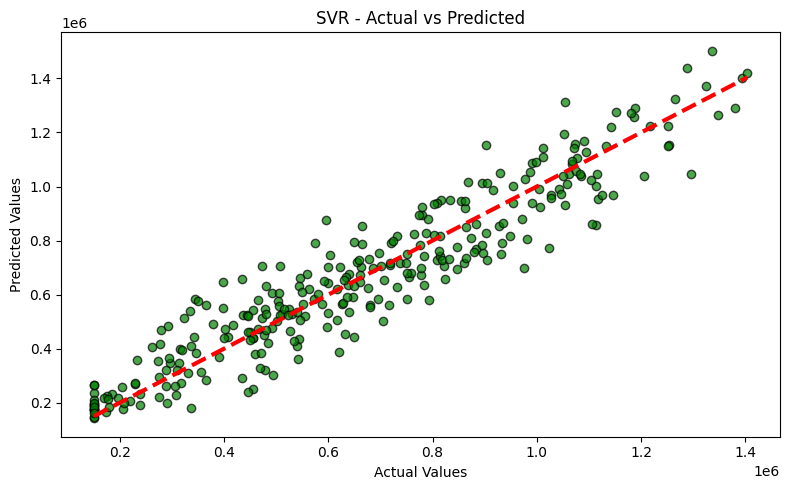

In [184]:
#Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='green', edgecolor='black', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--",  lw=3)  # Line for perfect predictions
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('SVR - Actual vs Predicted')
plt.tight_layout()
plt.savefig('HOUSE.png', dpi=150)
plt.show()

In [185]:
Powei.predict(poly_features.transform([[2]]))

array([0.34954184])